# L6d: Let's use a Modern Hopfield Network as a Synthetic Data Generator
In this lab, we build a modern Hopfield workflow that can both retrieve noisy market memories and generate synthetic return paths.

> __Learning Objectives:__
> By the end of this lab, you will be able to:
> * __Prepare market memories for Hopfield encoding:__ Build the growth-rate matrix from cleaned ticker data and convert each trading day into a memory vector. Normalize each day to zero mean and unit norm before model construction.
> * __Run the model in retrieval and generative modes:__ Test high inverse-temperature retrieval from a corrupted query and identify the recovered memory index. Run low inverse-temperature generation from a random query and interpret the resulting probability mixture over stored days.
> * __Evaluate synthetic-data realism with diagnostics:__ Compare generated and observed return distributions for selected tickers. Check linear autocorrelation and volatility clustering behavior using autocorrelation-based plots.

Let's get started!
___


## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Environment Setup__
> 
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment. The code block below returns `nothing::Nothing` and applies side effects by evaluating `Include.jl` in global scope.


In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We gathered a daily open-high-low-close `dataset` for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time.

Let's load `original_dataset::Dict{String,DataFrame}` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in `dataset::Dict{String,DataFrame}`.

The code block below returns `original_dataset::Dict{String,DataFrame}`, where each key is a ticker symbol and each value is that ticker's historical market dataframe.


In [2]:
original_dataset = MyTrainingMarketDataSet() |> x -> x["dataset"]; # load the original dataset

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or de-listing events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has a maximum value, e.g., `AAPL`, and save that value in `maximum_number_trading_days::Int64`. The code block below returns `maximum_number_trading_days::Int64`, which is the reference row count used to filter ticker histories.


In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # nrow? (check out: DataFrames.jl)

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in `dataset::Dict{String,DataFrame}`. The code block below returns `dataset::Dict{String,DataFrame}`, which stores only full-length ticker histories.

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # what is this doing?
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

How many firms do we have the full number of trading days? Let's use [the `length(...)` method](https://docs.julialang.org/en/v1/base/collections/#Base.length), which works for dictionaries in addition to arrays and sets.

In [5]:
length(dataset) # tells us how many keys are in the dictionary (how many firms in our dataset?)

424

Finally, let's get a list of the firms in our cleaned dataset (sorted alphabetically). We store the symbols in `list_of_tickers::Vector{String}`. The code block below returns `list_of_tickers::Vector{String}`, where each element is one ticker symbol.

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort # list of firm "ticker" symbols in alphabetical order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 ⋮
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Constants
Before we get to the main part of the lab, let's set constants that we will use later. We will use these constants to control model behavior and synthesis settings. See the comment next the constant for more information.

In [7]:
β = 100.0; # inverse temperature (high β means low temperature, which means more deterministic behavior; low β means high temperature, which means more stochastic behavior)

___

## Task 1: Compute the growth rate matrix
In this task, we compute the growth rate array which contains, for each day and each firm in our dataset, the value of the growth rate between time $j$ and $j-1$.

> __Continuously Compounded Growth Rate (CCGR):__
> 
> The daily price update for firm $i$ can be written using a continuously compounded return term.
> $$
\begin{align*}
S^{(i)}_{j} &= S^{(i)}_{j-1}\;\exp\left(\underbrace{g^{(i)}_{j,j-1}\Delta t_{j}}_{\text{return}}\right)
\end{align*}
> $$
> Here, $S^{(i)}_{j-1}$ is the price at time index $j-1$, $S^{(i)}_{j}$ is the price at time index $j$, and $\Delta t_{j}=t_j-t_{j-1}$ is the step length in years. The quantity we estimate from data is the return term $g^{(i)}_{j,j-1}\Delta t_{j}$. We've implemented [the `log_growth_rate(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/data/#VLDataScienceMachineLearningPackage.log_growth_matrix) which takes the cleaned up dataset and a list of ticker symbols and returns the growth rate array.

The code block below returns `G::Matrix{Float64}`, where each row is a trading day and each column is a ticker growth rate.


In [ ]:
G = let

    # initialize -
    r̄ = 0.0; # assume the risk-free rate is 0
    Δt = (1/252); # time step size (units: years)

    # compute the growth matrix -
    growth_rate_array = log_growth_matrix(dataset, list_of_tickers, Δt = Δt, 
        risk_free_rate = r̄); # other optional parameters are at their defaults
    
    growth_rate_array; # return
end;

In this application, the memory vectors we load are daily growth-rate vectors across all firms in the dataset, so each memory is one market day across tickers. Let's scale the data to have zero mean and unit length.

The code block below returns `(memories::Matrix{Float64}, scaled_memories::Matrix{Float64})`. The matrix `memories` stores raw daily vectors on columns, and `scaled_memories` stores centered, unit-norm versions of those same columns.


In [9]:
memories, scaled_memories = let

    # initialize -
    ϵ = 1e-12; # small number to avoid division by zero
    memories = transpose(G) |> Matrix; # each column is a memory vector (day in the market), and each row is a feature (a firm in the dataset)
    (number_of_rows, number_of_columns) = size(memories); # get the dimensions of the memories array

    # scale the memories to have zero-mean, and unit length
    scaled_memories = zeros(number_of_rows, number_of_columns);
    for i in 1:number_of_columns
        memory = memories[:,i]; # unscaled memory vector (day in the market)
        mean_memory = mean(memory); # what was the mean value for the growth rate that day (across all firms)?
        memory_centered = memory .- mean_memory; # center the memory vector by subtracting the mean value
        norm_memory_centered = norm(memory_centered) + ϵ; # compute the norm of the centered memory vector, and add a small number to avoid division by zero
        scaled_memories[:,i] = memory_centered ./ (norm_memory_centered + ϵ); # scale the memory vector to have unit length
    end
   
    # return -
    (memories, scaled_memories);
end;

If the scaling logic is correct, then the mean of each column of `scaled_memories::Matrix{Float64}` should be approximately zero, and the magnitude of each memory should be approximately `1`.

> __Memory Scaling Check:__
>
> Fill me in

So what do we see?

In [10]:
let

    # initialize -
    X = scaled_memories; # our input data (memories) for the Boltzmann machine
    number_of_memories = size(memories, 2); # how many memories do we have? (how many days of trading data do we have?)
    ϵ = 1e-10; # absolute tolerance for checking if the mean is approximately zero, and if the norm is approximately 1
    
    # Checks -
    for i ∈ 1:number_of_memories
        memory = X[:,i]; # get the i-th memory vector
        mean_memory = mean(memory); # compute the mean of the memory vector
        norm_memory = norm(memory); # compute the norm of the memory vector
        
        @assert isapprox(mean_memory, 0.0; atol = ϵ) "Mean of memory vector $i is not approximately zero: mean = $mean_memory"
        @assert isapprox(norm_memory, 1.0; atol = ϵ) "Norm of memory vector $i is not approximately 1: norm = $norm_memory"
    end
end

If we get here, and there were no errors then our scaling logic was correct, and we can now build our modern Hopfield network model.

### Encode a modern Hopfield model
Now that we have the training images, let's encode the model. We'll construct [a `MyModernHopfieldNetworkModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyModernHopfieldNetworkModel) using a custom [`build(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build).

> __How do we build this model?__
> We call [the `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build) with the model type, the raw memory matrix, the normalized memory matrix, and the inverse temperature $\beta$. The returned object stores the encoded memories and model parameters needed for recovery.

The code block below returns `model::MyModernHopfieldNetworkModel`, which is the retrieval model instance used in Task 2.


In [11]:
model = build(MyModernHopfieldNetworkModel, (
    memories = memories, # this is the data we want to memorize. Images on columns
    normalized_memories = scaled_memories, # normalized images on columns
    β = β, # Inverse temperature of the system. A big beta means we are more likely to get a definitive answer, small beta means more stochastic behavior
));

___

## Task 2: Let's run the Hopfield model in retrieval mode
In this task, we'll run the modern Hopfield network in retrieval mode, i.e., with $\beta\gg{1}$ (small temperature, which means more deterministic behavior). We'll give the model corrupted versions of market behavior on a given day, and see if the model can retrieve the original memory.

> __What are we doing in the code block below?__
> We randomly select one stored market day, add Gaussian noise, and use the noisy vector as the query state. This gives us a controlled retrieval test because we know the true memory index.

The code block below returns `(s₁::Vector{Float64}, ŝ₁::Vector{Float64}, i₁::Int64)`, where `s₁` is the true memory, `ŝ₁` is the corrupted query, and `i₁` is the true memory index.


In [12]:
s₁,ŝ₁,i₁ = let 
    
    # select a random memory vector (day in the market) from the dataset
    number_of_memories = size(memories, 2); # how many memories do we have? (how many days of trading data do we have?)
    random_index = rand(1:number_of_memories); # select a random index
    original_memory = memories[:, random_index]; # get the original memory vector (the original market behavior for that day)
    σ = 0.5; # standard deviation of the noise to add to the memory vector

    # corrupt the memory vector by adding some noise to it
    noise = σ * randn(size(original_memory)); # generate some random noise
    corrupted_memory = original_memory + noise; # add the noise to the original memory vector to get the corrupted memory vector

    # return -
    (original_memory, corrupted_memory, random_index);
end;

Now that we have a corrupted initial memory $\hat{\mathbf{s}}_{1}$, can the network recover the original memory? Let's call [the `recover(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.recover-Union{Tuple{T},%20Tuple{MyModernHopfieldNetworkModel,%20Vector{T}}}%20where%20T%3C:Number) below to perform memory retrieval from the corrupted initial state.

The next code block returns `(m̂ᵢ::Vector{Float64}, f₁::Vector{Float64}, p₁::Vector{Vector{Float64}})`, where `m̂ᵢ` is the recovered state, `f₁` stores iteration metrics, and `p₁` stores the probability vector history. 

In [13]:
(m̂ᵢ,f₁,p₁) = recover(model, ŝ₁, maxiterations = 10000, ϵₚ = 1e-12, ϵₛ = 1e-12); # iterate until we hit stop condition

In [14]:
println("How many iterations: $(length(f₁))") # how many iterations did we need to converge?

How many iterations: 3


The recovered memory index is stored in the `î₁::Int64` variable:

In [15]:
î₁ = let
    î₁ = p₁[length(f₁) - 1] |> x-> argmax(x) # probability of each memory at iteration at the last iteration
    println("Original memory index: $i₁, recovered memory index: $î₁")
    î₁; # return the index we think the memory corresponds 
end;

Original memory index: 902, recovered memory index: 902


How close is the corrupted memory to the true memory, or the recovered memory to the true memory? Let's first compute the $l_2$ distance between the corrupted memory and the true memory, and between the recovered memory and the true memory. For comparison later, we'll store the __unscaled__ recovered memory from the final probability vector in `m₁::Vector{Float64}`.

In [16]:
m₁ = let

    # initialize -
    M = memories;
    p = p₁[length(f₁) - 1]; # probability of each memory at iteration at the last iteration
    m = M*p; # this is the retrieved memory vector (the model's best guess for the original memory vector)
    
    # compute the distance between the retrieved memory and the original memory
    d = norm(m - s₁); # compute the distance between the retrieved memory and the original memory
    println("Distance between retrieved memory and true memory: $d")

    # compute the distance between the true memory and the corrupted memory
    d₂ = norm(s₁ - ŝ₁); # compute the distance between the true memory and the corrupted memory
    println("Distance between true memory and corrupted memory: $d₂")

    m; # this is the *unscaled* memory
end;

Distance between retrieved memory and true memory: 0.0
Distance between true memory and corrupted memory: 11.100920204836159


The following block returns `comparison_matrix::Matrix{Float64}` with columns `[m₁ s₁ ŝ₁]` for side-by-side inspection.

In [17]:
[m₁ s₁ ŝ₁] # recovered memory, original (true) memory, initial corrupted memory

424×3 Matrix{Float64}:
  1.34902    1.34902    0.859407
  1.65717    1.65717    2.1081
 -6.10304   -6.10304   -6.11944
 -3.19087   -3.19087   -3.49127
  1.26899    1.26899    0.546399
  0.147305   0.147305   1.50102
  1.87933    1.87933    2.64155
  1.85419    1.85419    2.01659
 -2.93707   -2.93707   -3.37779
  1.20392    1.20392    1.55692
  ⋮                    
  1.18665    1.18665    0.97523
  1.71812    1.71812    0.963907
  0.280237   0.280237   0.343647
  0.855754   0.855754   1.39624
 -1.92716   -1.92716   -2.27162
 -3.475     -3.475     -3.43999
 -4.09187   -4.09187   -3.46196
  0.244275   0.244275   0.104387
  2.11763    2.11763    2.28264

___

## Task 3: Let's run the Hopfield model in generative mode
In this task, we'll run the modern Hopfield network in generative mode, i.e., with $\beta\ll{1}$ (high temperature, which means more stochastic behavior). We'll give the model a random vector as input and generate a weighted combination of stored memories.

The code block below returns `generative_model::MyModernHopfieldNetworkModel`, which is the low-$\beta$ model instance used for synthesis.


In [18]:
generative_model = build(MyModernHopfieldNetworkModel, (
    memories = memories, # raw memories on columns
    normalized_memories = scaled_memories, # normalized memories on columns
    β = 0.3, # small beta -> high temperature -> diffuse probabilities (generative mode)
));

For generative mode, we will *not* start from a known day. Instead, we use a random query vector as the initial state and let the model produce a probability distribution over stored memories. When this probability vector is diffuse, we can optionally project it to a top-`k` support (and renormalize) before forming a weighted memory, which reduces cancellation from near-uniform averaging.

> __What is going on in the code block below?__
> We create a random query with the same number of features as the stored memories and rescale it to a comparable norm. This keeps the query in a realistic magnitude range for memory lookup.

The code block below returns `ŝ₂::Vector{Float64}`, the random initial query used in __generative mode__.


In [19]:
ŝ₂ = let

    # Build a random query with a comparable scale to the stored market memories
    
    # initialize -
    number_of_features = size(memories, 1); # how many firms (features) do we have in our dataset?
    target_norm = mean(norm(memories[:, i]) for i ∈ 1:size(memories, 2)); # "scale" of the memories (average norm of the memory vectors)
    
    # create a radom vector with the same number of features as the memories, and a norm comparable to the memories
    s = randn(number_of_features); # random vector, standard normal distribution
    s ./= (norm(s) + 1e-12); # normalize the random vector to have unit length (add a small number to avoid division by zero)
    s .*= target_norm; # scale the random vector to have a norm comparable to the memories

    s; # return the random query vector
end;

Now let's call [the `recover(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.recover-Union{Tuple{T},%20Tuple{MyModernHopfieldNetworkModel,%20Vector{T}}}%20where%20T%3C:Number) with this random query to obtain an iterative probability distribution over memories. The code block below returns `(m̂₂::Vector{Float64}, f₂::Vector{Float64}, p₂::Vector{Vector{Float64}})`, where `p₂` is the probability-vector trajectory and the final entry is used for generation.

In [20]:
(m̂₂,f₂,p₂) = recover(generative_model, ŝ₂, maxiterations = 10000, ϵₚ = 1e-12, ϵₛ = 1e-12); # iterate until we hit stop condition

The code block below analyzes the final probability vector over memories. It reports the dominant memory index and computes entropy, where higher entropy indicates a more diffuse mixture and lower entropy indicates a more concentrated mixture.

> __What is the entropy of the final probability vector, and which memory is dominant?__
> Let the final probability vector be `p::Vector{Float64}` from the last recovery step. The [Shannon entropy](https://en.wikipedia.org/wiki/Entropy_(information_theory)) of this probability distribution is computed as $H(p) = -\sum_i p_i\log p_i$ (units: nats), and the dominant memory is `î₂::Int64 = argmax(p)`.
> If $H(p)\approx 0$, most probability mass is concentrated on one memory, so the model is behaving like retrieval. If $H(p)$ is closer to $\log(K)$, where $K = \mathrm{length}(p)$, the distribution is close to uniform and the model is producing a broad mixture over many memories.

The code block below returns `î₂::Int64`, the dominant memory index from the final probability vector.

In [45]:
î₂ = let
    p = p₂[length(f₂) - 1];
    i = argmax(p);
    H = -sum(pi > 0 ? pi*log(pi) : 0.0 for pi ∈ p); # Wow! This is fancy shorthand generating a list, and then summing over the list
    println("Dominant memory index: $i")
    println("max(p) = ", round(maximum(p), digits=6), ", min(p) = ", round(minimum(p), digits=6), ", entropy(p) = ", round(H, digits=3),", log(K) = ", round(log(length(p)), digits=3));
    i;
end;

Dominant memory index: 1646
max(p) = 0.000363, min(p) = 0.00036, entropy(p) = 7.925, log(K) = 7.925


What is the generated (unscaled) memory? We compute two versions: (i) full mixture `M*p`, and (ii) top-`k` projected mixture, where only the largest `k` probabilities are kept and renormalized.

The next code block returns `(m₂::Vector{Float64}, m₂_topk::Vector{Float64})`, where `m₂` is the full mixture and `m₂_topk` is the top-`k` projected mixture. The following block returns `generative_comparison_matrix::Matrix{Float64}` with columns `[m₂ m₂_topk ŝ₂ memories[:,î₂]]`.


In [22]:
m₂, m₂_topk = let

    # initialize -
    M = memories;
    p = p₂[length(f₂) - 1]; # final probability vector over memories
    m = M*p; # full mixture memory

    # top-k projected mixture to reduce cancellation from diffuse p
    k = 25; # change this to tune sharpness
    sorted_idx = sortperm(p, rev=true); # sort the indices of p in descending order
    keep = sorted_idx[1:min(k, length(sorted_idx))];
    q = zeros(length(p));
    q[keep] = p[keep];
    q ./= (sum(q) + 1e-12);
    m_topk = M*q;

    println("norm(random query) = ", round(norm(ŝ₂), digits=3))
    println("norm(full mixture M*p) = ", round(norm(m), digits=3))
    println("norm(top-k mixture) = ", round(norm(m_topk), digits=3), " with k = ", k)

    (m, m_topk);
end;

norm(random query) = 83.132
norm(full mixture M*p) = 2.379
norm(top-k mixture) = 53.654 with k = 25


In [23]:
[m₂ m₂_topk ŝ₂ memories[:,î₂]] # generated full mixture, generated top-k mixture, random initial query, original memory corresponding to the most probable memory index

424×4 Matrix{Float64}:
  0.110078    3.16647   -4.79693     3.7102
 -0.0377268  -0.54284   -5.22239   -11.5544
 -0.0805417  -0.297283   2.29006    -0.401931
  0.234874    4.88004    4.63664     2.49913
  0.111485    1.44717   -5.17059    -2.03694
  0.0989961   2.26753   -2.68497     1.41724
  0.134351    2.60974    4.23052     1.97575
  0.186817    6.8626     8.45731    11.4211
  0.134493    3.43787    2.03295     0.401211
  0.0130802  -1.73454   -2.85728    -4.40401
  ⋮                                
 -0.0754748  -0.069849  -3.30516    -7.41585
  0.0813259  -0.253207  -2.28266    -0.122429
  0.0050065  -2.67135   -0.440082   -5.89843
 -0.0859152  -0.246269   3.82891    -5.2602
  0.110797    0.521925  -2.82194    -1.08899
  0.0524719   0.914537  -5.25838     0.407104
  0.1813      3.72582    2.85919     1.93283
  0.0529594  -4.50996    4.00635    -5.9092
  0.148977    3.30308   -0.769504    2.59657

## Extra: Fun with the generated data
If this works, we should be able to generate return trajectories for assets in the network that have realistic statistical structure. Let's compare generated and observed data.

First, let's generate synthetic data by iterating the generative process above.

The code block below returns `Ĝ::Matrix{Float64}` with dimensions `(number_of_synthetic_days, number_of_synthetic_firms)`, where each row is one synthetic day and each column is one ticker.

In [34]:
Ĝ = let

    # initialize -
    number_of_synthetic_days = maximum_number_trading_days; # how many synthetic days to generate
    number_of_synthetic_firms = length(list_of_tickers); # number of firms (features)
    sₒ = ŝ₂; # initial query state
    Ĝ = Array{Float64,2}(undef, number_of_synthetic_days, number_of_synthetic_firms);

    # memory-mixture controls -
    k = 25; # top-k support for memory mixing
    γ_sharpen = 4.0; # sharpen q to reduce over-smoothing
    λ_q = 0.00; # keep near 0 to avoid strong raw-return autocorrelation
    σ_select = 1e-5; # small jitter for stochastic tie-breaking in top-k

    # query-state controls -
    λ_query = 0.00; # keep near 0 for weak raw-return autocorrelation
    σ_query = 0.10; # additive noise in query evolution

    # latent volatility state h_t (AR(1) in log-vol) -
    ρ_logh = 0.98; # volatility persistence
    σ_logh = 0.30; # volatility shock scale (increase for stronger clustering)
    logh = 0.0;

    # optional post-adjustments -
    match_ticker_means = true;  # shift generated per-ticker means to match original means
    match_ticker_stds = true;  # keep false when evaluating volatility clustering
    α_std = 1.0; # partial std scaling if match_ticker_stds=true

    # constants -
    M = memories; # raw memories on columns (features x memory_index)
    number_of_memories = size(M, 2);
    μ_orig = vec(mean(G, dims=1));
    σ_orig = vec(std(G, dims=1));
    q_prev = fill(1.0/number_of_memories, number_of_memories);

    for t ∈ 1:number_of_synthetic_days

        # recover probabilities over memories from current query
        (m̂, f, p) = recover(generative_model, sₒ, maxiterations = 100, ϵₚ = 1e-12, ϵₛ = 5e-1);
        last_probability = p[length(f) - 1];

        # stochastic top-k proposal q_new
        selection_scores = last_probability .+ σ_select*randn(length(last_probability));
        sorted_idx = sortperm(selection_scores, rev=true);
        keep = sorted_idx[1:min(k, length(sorted_idx))];

        q_new = zeros(length(last_probability));
        q_new[keep] = last_probability[keep];
        q_new ./= (sum(q_new) + 1e-12);

        # sticky mixture weights for temporal persistence
        q = λ_q*q_prev + (1 - λ_q)*q_new;
        q ./= (sum(q) + 1e-12);

        # sharpen then renormalize
        q .^= γ_sharpen;
        q ./= (sum(q) + 1e-12);

        # base generated vector from memory mixture
        m_raw = M*q;

        # latent volatility update: log h_t = ρ log h_{t-1} + σ ε_t
        logh = ρ_logh*logh + σ_logh*randn();
        h = exp(logh);

        # apply scalar volatility modulation around per-ticker historical mean
        m_topk = μ_orig .+ sqrt(h).*(m_raw .- μ_orig);

        # store generated day
        Ĝ[t, :] = m_topk;

        # evolve query state with persistence + noise (do not hard-normalize)
        sₒ = λ_query*sₒ + (1 - λ_query)*m_topk + σ_query*randn(length(m_topk));

        # carry state
        q_prev = q;
    end

    # optional first/second-moment matching per ticker
    if match_ticker_means || match_ticker_stds
        μ_gen = vec(mean(Ĝ, dims=1));
        σ_gen = vec(std(Ĝ, dims=1));

        if match_ticker_stds
            scale = (σ_orig ./ (σ_gen .+ 1e-12)) .^ α_std;
            Ĝ .-= reshape(μ_gen, 1, :);
            Ĝ .*= reshape(scale, 1, :);
            Ĝ .+= reshape(μ_orig, 1, :);
        elseif match_ticker_means
            Ĝ .+= reshape(μ_orig .- μ_gen, 1, :);
        end
    end

    println("Generated days: ", number_of_synthetic_days, ", unique rows (rounded 1e-10): ", length(unique(eachrow(round.(Ĝ, digits=10)))));
    println("Mean alignment check (avg |Δμ|): ", mean(abs.(vec(mean(Ĝ, dims=1)) .- μ_orig)));
    println("Std alignment check (avg |Δσ|): ", mean(abs.(vec(std(Ĝ, dims=1)) .- σ_orig)), " (α_std = ", α_std, ")");

    Ĝ;
end



Generated days: 2767, unique rows (rounded 1e-10): 2767
Mean alignment check (avg |Δμ|): 7.073364379722279e-17
Std alignment check (avg |Δσ|): 2.9802104180691483e-12 (α_std = 1.0)


2767×424 Matrix{Float64}:
  4.08326     1.02993     5.02273    …   3.74553    8.35767    0.502742
 -1.66014     7.76146     2.93007       -0.397581  -0.159172   1.22548
  1.78797     6.98256     2.93618        0.564323   4.25706    1.46651
 -0.370957   -0.884305  -15.912         -1.84586   -0.159868  -0.249917
  3.38403    -6.24549     8.10481       -2.06572    5.8358     1.73602
 -2.22766    -2.58095    -6.93803    …   0.748246   1.20951   -3.51635
  0.322106   -2.86169     1.12356       -1.57622    0.896841   2.51976
  2.48711     2.39962    -9.21361        7.24298    3.19448    2.592
  1.92552     7.5396      2.39794        1.73692    5.76635    0.313801
 -0.0653532  10.2074      4.81694        1.47597    3.18449   -0.0867487
  ⋮                                  ⋱                        
 -1.65061     1.16046    -5.87447        0.946078   1.76218    0.934078
 -0.106039    0.179413    1.45818       -0.298574   1.2791     0.34811
  0.230386   -3.78333    -0.0243395  …   0.494223  -0.7

Let's look at a specific ticker and compare generated data to original data.

The code block below returns `ticker_to_compare::String`, the ticker symbol used in downstream plots.


In [35]:
ticker_to_compare = "AAPL"; # which ticker do we want to compare between the original and generated data?

The code block below overlays return-density estimates for the selected ticker in observed and generated data.

The code block below returns `return_density_plot::Any`, the plot object for the return-distribution comparison.


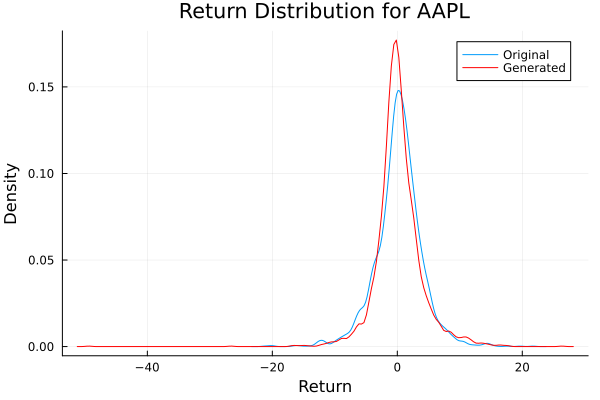

In [36]:
let

    # initialize -
    ticker_index = findfirst(==(ticker_to_compare), list_of_tickers); # find the index of the ticker we want to compare

    # let's plot the return distribution -
    density(G[:, ticker_index], label="Original", title="Return Distribution for $ticker_to_compare", xlabel="Return", ylabel="Density")
    density!(Ĝ[:, ticker_index], label="Generated", color=:red)
end

### Auto-correlation structure of the generated data
Let's check if the generated data has a similar auto-correlation structure to the original data by comparing observed and generated autocorrelation curves.

The code block below returns `autocorrelation_plot::Any`, the lag-autocorrelation comparison plot.


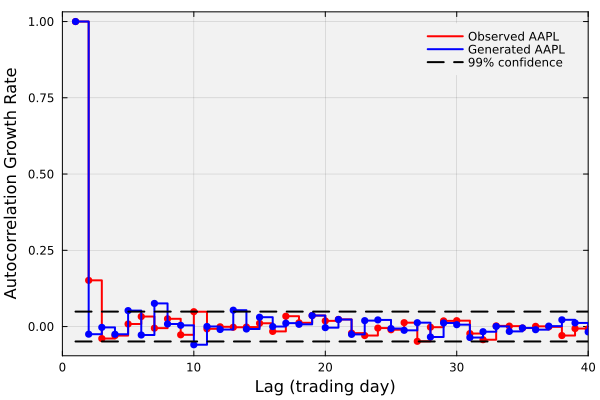

In [37]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 40
    X = G[:,i]; # TODO: change to Ĝ to compare the generated data instead of the original data
    X̂ = Ĝ[:,i]; # this is the generated data for the same ticker
    
    # Observed autocorrelation for the original data
    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red, 
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, 
        linetype=:steppost, xlims=(0,max_number_of_steps_x))
    scatter!(autocor(X, (0:(number_of_steps - 1) |> collect)), label="", c=:red, msc=:red)
    
    # Autocorrelation for the generated data
    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue, linetype=:steppost)
    scatter!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="", c=:blue, msc=:blue)
    
    # Confidence intervals for null hypothesis of no autocorrelation (dashed lines)
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation Growth Rate", fontsize=18)

    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end

### Volatility clustering
Next, let's consider volatility clustering. Volatility clustering is determined by examining autocorrelation of squared returns at different lags.

The code block below returns `volatility_clustering_plot::Any`, the squared-return autocorrelation comparison plot.


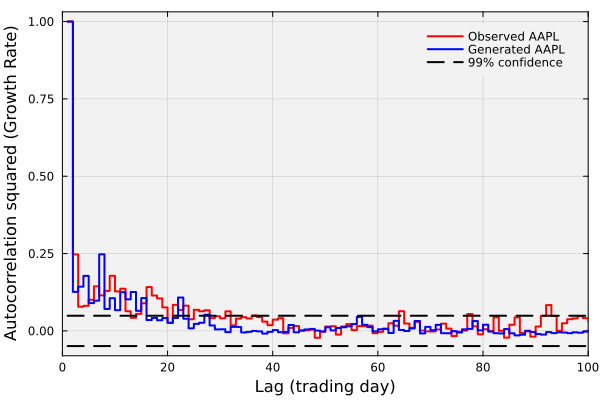

In [38]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 100
    X = (G[:,i]).^2;
    X̂ = (Ĝ[:,i]).^2;

    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))

    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))
    
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation squared (Growth Rate)", fontsize=18)

    
    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end

## Summary
This lab builds a modern Hopfield pipeline that transforms historical multi-ticker return days into memories, then uses retrieval and generative queries to reconstruct or synthesize market states.

> __Key Takeaways:__
> * __Memory design controls model behavior:__ Each stored memory is one daily cross-sectional return vector across firms, and normalization enforces a consistent scale before encoding. This setup makes retrieval and generation comparisons easier because all memories share the same preprocessing assumptions.
> * __Retrieval and generation use the same core mechanism:__ High inverse-temperature queries produce concentrated memory probabilities and support near-nearest-memory recovery from noisy inputs. Low inverse-temperature queries produce diffuse probabilities that behave like weighted mixtures of market days.
> * __Diagnostics must include both shape and dependence:__ Distribution comparisons show whether synthetic returns capture center and tail behavior for selected tickers. Autocorrelation and volatility-clustering plots show whether temporal structure is preserved beyond marginal distributions.

This workflow gives a reusable template for testing how memory-based generative models capture stylized facts in financial return data.
___
